In [1]:
# Import required modules
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import Point
import xarray as xr
import contextily as ctx
from adjustText import adjust_text  # pip install adjustText
from pathlib import Path

# Add that all figures should be inlined
%matplotlib inline
#%matplotlib notebook

## Read data

In [5]:
swe_observations_path = '/Users/dcasson/Data/snow_data/NorSWE/Bow_NorSWE.nc'

working_dir = '/Users/dcasson/Data/summa_snakemake/bow_tdx/'
image_dir = Path(working_dir) / 'images'
image_dir.mkdir(parents=True, exist_ok=True)
basin_gpkg_path = Path(working_dir) / 'watershed_tools/final/bow_tdx.gpkg'
hru_ids_csv = Path(working_dir) / 'hrus_with_ids.csv'


In [6]:
# Read SWE station observations NetCDF
SWE_stations_ds = xr.open_dataset(swe_observations_path)

# Convert SWE stations DataArray to GeoDataFrame for further analysis
data = {'station_id': SWE_stations_ds.station_id.data, 
        'station_name': SWE_stations_ds.station_name.data,
        'lon': SWE_stations_ds.lon.data, 
        'lat': SWE_stations_ds.lat.data} 
df = pd.DataFrame(data)
geometry = [Point(xy) for xy in zip(df['lon'], df['lat'])]
crs = "EPSG:4326"
SWE_stations_gdf = gpd.GeoDataFrame(df, crs=crs, geometry=geometry)

# Read basin shapefile
basins_gdf = gpd.read_file(basin_gpkg_path)
basins_gdf = basins_gdf.to_crs("EPSG:4326")
buffer_km_default =0

print(SWE_stations_gdf.head())
print(basins_gdf.head())


           station_id            station_name         lon        lat  \
0  CanSWE-ALE-05BA811        BOW SUMMIT (OLD) -116.466667  51.700001   
1    CanSWE-SCD-AL003                   BANFF -115.566666  51.183334   
2    CanSWE-SCD-AL022        CALGARY INT\'L A -114.016670  51.099998   
3    CanSWE-SCD-AL082    KANANASKIS POCATERRA -115.116669  50.700001   
4   CanSWE-UU-MC-FisS  Fisera_Lower_Southface -115.204018  50.955975   

                      geometry  
0  POINT (-116.46667 51.70000)  
1  POINT (-115.56667 51.18333)  
2  POINT (-114.01667 51.10000)  
3  POINT (-115.11667 50.70000)  
4  POINT (-115.20402 50.95597)  
   streamID       areaSqm         elev      slope      aspect  vegType  \
0         1  9.765123e+06  2256.530518  22.695560  228.997253        1   
1         2  1.581540e+07  2426.980469  25.695826  195.401077        1   
2         3  6.390765e+06  2548.875244  32.396725  291.918762        3   
3         4  1.165965e+07  2593.581055  21.907070   76.104248        1   

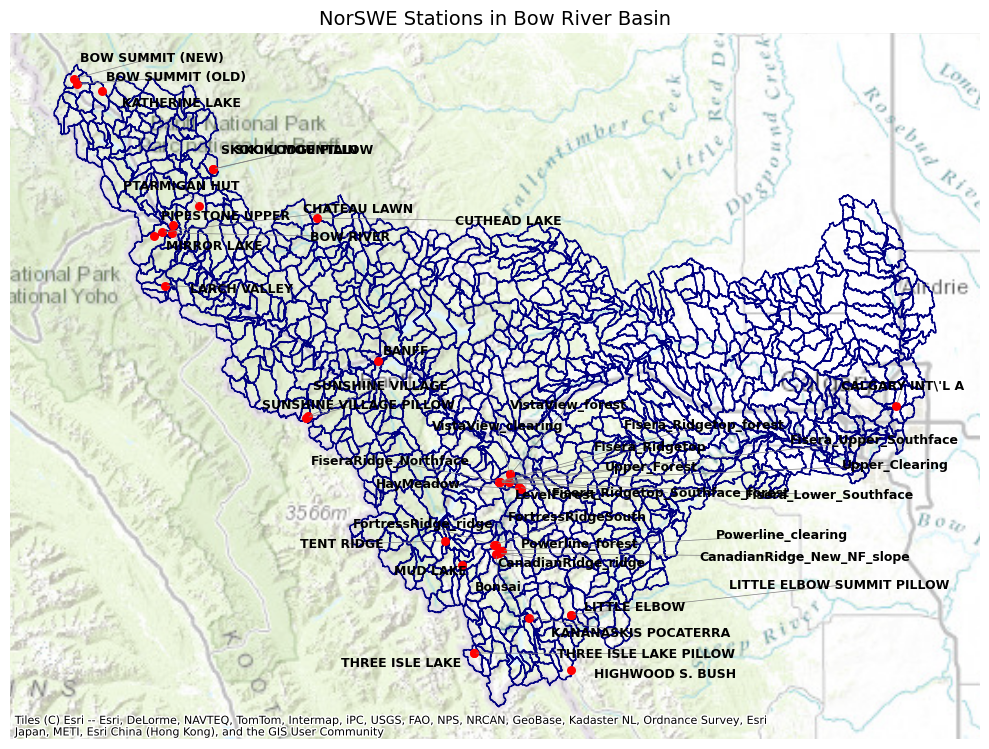

<Figure size 640x480 with 0 Axes>

In [7]:
# Project to Web Mercator for contextily
basins_gdf_proj = basins_gdf.to_crs(epsg=3857)
SWE_stations_gdf_proj = SWE_stations_gdf.to_crs(epsg=3857)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the basin outlines
basins_gdf_proj.plot(ax=ax, facecolor='none', edgecolor='navy', linewidth=1)

# Plot the SWE stations
SWE_stations_gdf_proj.plot(ax=ax, color='red', markersize=30, zorder=3)

# Use adjustText to reduce label overlap
texts = []
for x, y, label in zip(
        SWE_stations_gdf_proj.geometry.x, 
        SWE_stations_gdf_proj.geometry.y, 
        SWE_stations_gdf_proj['station_name']):
    texts.append(ax.text(x, y, label, fontsize=9, fontweight='bold', color='black', zorder=4))

adjust_text(texts, ax=ax, expand_points=(1.2, 1.6), arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

# Add a hydrology-friendly basemap (Stamen Terrain or ESRI World Topo)
ctx.add_basemap(
    ax, 
    crs=basins_gdf_proj.crs.to_string(), 
    source=ctx.providers.Esri.WorldTopoMap,  # Or ctx.providers.Esri.WorldTopoMap
    alpha=0.8
)

ax.set_title('NorSWE Stations in Bow River Basin', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()
plt.savefig(image_dir / 'bow_basin_stations.png')

In [8]:
import geopandas as gpd
import xarray as xr
from shapely.geometry import Point

def read_and_convert_shapefile(shp_file):
    # Load the shapefile
    gdf = gpd.read_file(shp_file)
    
    # Ensure geometries are valid
    gdf['geometry'] = gdf['geometry'].apply(lambda geom: geom.buffer(0) if not geom.is_valid else geom)
    
    # Explode multi-part geometries into single-part geometries
    gdf = gdf.explode(index_parts=False)
    
    return gdf

def get_hru_ids(shp_file, nc_file):
    gdf = read_and_convert_shapefile(shp_file)
    
    ds = xr.open_dataset(nc_file)
    
    lats = ds['lat'].values
    lons = ds['lon'].values
    
    stations = gpd.GeoDataFrame({'latitude': lats, 'longitude': lons})
    stations['geometry'] = stations.apply(lambda row: Point(row['longitude'], row['latitude']), axis=1)
    stations.set_crs(epsg=4326, inplace=True)
    
    joined = gpd.sjoin(stations, gdf, how='left', op='within')
    
    hru_ids = joined['HRU_ID']

    
    #drop nan values
    hru_ids = hru_ids.dropna()
    # Add lat lon and station_name to the hru_ids
    hru_ids = hru_ids.to_frame()
    hru_ids['lat'] = lats[hru_ids.index]
    hru_ids['lon'] = lons[hru_ids.index]
    hru_ids['station_name'] = ds['station_name'].values[hru_ids.index]
    hru_ids['station_id'] = ds['station_id'].values[hru_ids.index]
    return hru_ids

hru_ids = get_hru_ids(basin_gpkg_path,swe_observations_path)
# Export to csv
hru_ids.to_csv(hru_ids_csv)
print(f'HRU IDs exported to {hru_ids_csv}')

HRU IDs exported to /Users/dcasson/Data/summa_snakemake/bow_tdx/hrus_with_ids.csv


/var/folders/46/6y3tkg051374dmsgd2w6l9gw0000gn/T/ipykernel_18976/2913873185.py:26: FutureWarning: You are adding a column named 'geometry' to a GeoDataFrame constructed without an active geometry column. Currently, this automatically sets the active geometry column to 'geometry' but in the future that will no longer happen. Instead, either provide geometry to the GeoDataFrame constructor (GeoDataFrame(... geometry=GeoSeries()) or use `set_geometry('geometry')` to explicitly set the active geometry column.
  stations['geometry'] = stations.apply(lambda row: Point(row['longitude'], row['latitude']), axis=1)
/Users/dcasson/.pyenv/versions/gpep_snakemake/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3526: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [39]:
import os
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import matplotlib.dates as mdates

def read_station_data(station_file, station_name):
    ds = xr.open_dataset(station_file)
    station_names = ds['station_name'].values
    if station_name in station_names:
        station_index = list(station_names).index(station_name)
        return ds.isel(station_id=station_index)['snw']
    else:
        raise ValueError(f"Station '{station_name}' not found in the file.")

def read_model_data(model_file, variable_name, dimension_name, dimension_value):
    ds = xr.open_dataset(model_file)
    return ds.sel({dimension_name: dimension_value})[variable_name]

def plot_models(station_file, station_name, variable_name, dimension_name, dimension_value, model_files, model_labels, output_path):
    station_data = read_station_data(station_file, station_name)

    # Prepare time axis
    time = None

    plt.figure(figsize=(12, 6))

    # Plot station data
    if 'time' in station_data.dims:
        time = pd.to_datetime(station_data['time'].values)
        plt.scatter(time, station_data.values, color='black', s=18, label=station_name, zorder=10)
    else:
        raise ValueError("Expected 'time' dimension in station_data")

    # Plot each model
    for model_file, label in zip(model_files, model_labels):
        model_data = read_model_data(model_file, variable_name, dimension_name, dimension_value)
        model_time = pd.to_datetime(model_data['time'].values)
        plt.plot(model_time, model_data.values, label=label, linewidth=2)

    plt.title(f'Model Comparison of {variable_name} for {station_name}')
    plt.xlabel('Time')
    plt.ylabel(variable_name)
    plt.legend(loc='upper right')

    plt.xlim(pd.to_datetime('2010-08-01'), pd.to_datetime('2019-12-31'))
    plt.savefig(output_path)
    plt.close()

# --- USAGE ---

stations_file = hru_ids_csv
stations_df = pd.read_csv(stations_file)

figure_directory = Path(image_dir)
station_file = swe_observations_path
figure_directory.mkdir(exist_ok=True)

# List of model files and their display labels
model_files = [
    '/Users/dcasson/Data/bow_snow_experiments/lumped/output/run1_timestep.nc',
    # Add more models here
]
model_labels = [
    'CASR',
    # Add more labels here
]

for _, row in stations_df.iterrows():
    station_name = row['station_name']
    hru_id = int(row['HRU_ID'])
    output_plot_path = f'{figure_directory}/model_plot_{station_name}_HRU_{hru_id}.png'
    hru_id = 101
    plot_models(
        station_file, station_name,
        'scalarSWE', 'hru', hru_id,
        model_files, model_labels,
        output_plot_path
    )

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

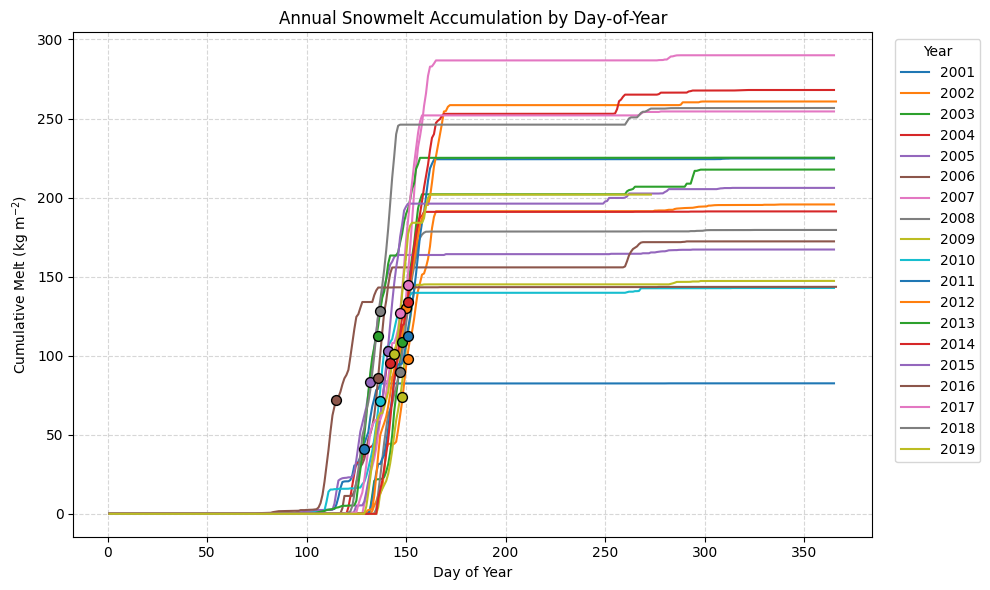

In [59]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from typing import Tuple, Optional

def plot_snowmelt_by_doy(nc_path: str, start_date: Optional[str] = None, end_date: Optional[str] = None) -> Tuple[plt.Figure, plt.Axes]:
    """
    Plot annual snowmelt accumulation as a function of day‐of‐year.

    Parameters
    ----------
    nc_path : str
        Path to the NetCDF file containing `scalarSWE(time, hru)` and CF‐compliant `time` coordinate.
    start_date : str, optional
        Start date for the time constraint in 'YYYY-MM-DD' format.
    end_date : str, optional
        End date for the time constraint in 'YYYY-MM-DD' format.

    Returns
    -------
    fig : matplotlib.figure.Figure
        The figure object containing the plot.
    ax : matplotlib.axes.Axes
        The axes object of the plot.
    """
    # 1. Open dataset and select first HRU
    ds = xr.open_dataset(nc_path, decode_times=True)
    
    # Apply time constraints if provided
    if start_date or end_date:
        ds = ds.sel(time=slice(start_date, end_date))
    
    swe = ds["scalarSWE"].isel(hru=0).to_series()

    # 2. Ensure datetime index
    swe.index = pd.to_datetime(swe.index)

    # 3. Resample to daily (end‐of‐day SWE)
    swe_daily = swe.resample("D").last().dropna()

    # 4. Group by calendar year
    grouped = swe_daily.groupby(swe_daily.index.year)

    fig, ax = plt.subplots(figsize=(10, 6))

    for year, series in grouped:
        # 5a. Identify ablation period start (day of max SWE)
        peak_time = series.idxmax()

        # 5b. Compute daily melt: positive drop from previous day
        melt = (series.shift(1) - series).clip(lower=0)
        melt.loc[:peak_time] = 0.0

        # 5c. Cumulative melt time‐series
        cum_melt = melt.cumsum()

        # 5d. Mid‐point day‐of‐year
        total = cum_melt.max()
        half = total / 2.0
        try:
            mid_time = cum_melt[cum_melt >= half].index[0]
            mid_doy = mid_time.dayofyear
        except IndexError:
            # if no melt, skip
            continue

        # Plot
        doy = series.index.dayofyear
        ax.plot(doy, cum_melt, label=str(year))
        ax.scatter(mid_doy, half, s=50, edgecolor="k", zorder=3)

    # 7. Decorate
    ax.set_xlabel("Day of Year")
    ax.set_ylabel("Cumulative Melt (kg m$^{-2}$)")
    ax.set_title("Annual Snowmelt Accumulation by Day‐of‐Year")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, prune="both"))
    ax.legend(title="Year", bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout()

    return fig, ax

# Example usage
if __name__ == "__main__":
    fig, ax = plot_snowmelt_by_doy("/Users/dcasson/Data/bow_snow_experiments/lumped/output/run1_timestep.nc", start_date="2001-01-01", end_date="2019-12-31")
    plt.show()

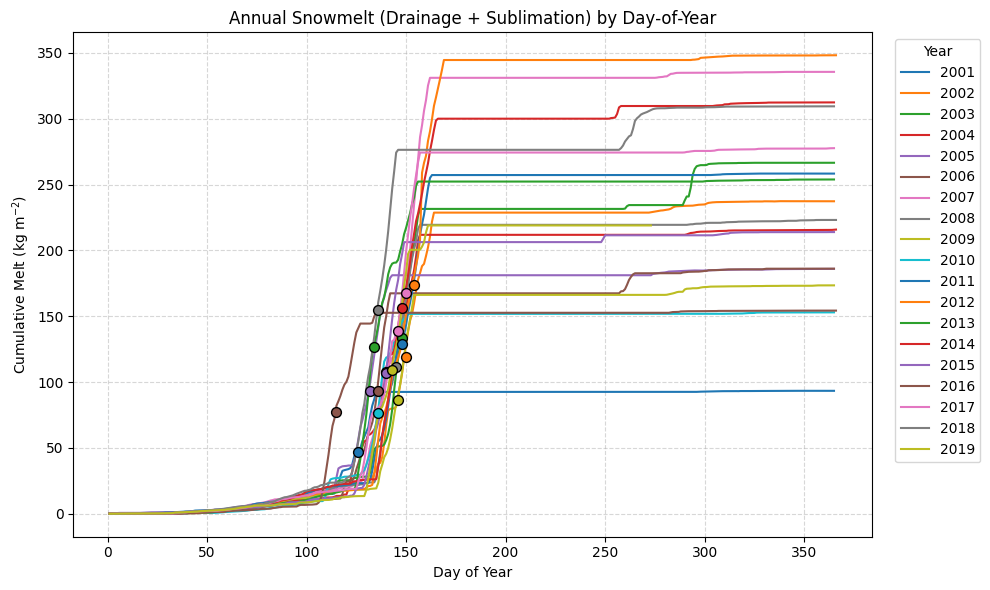

In [60]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from typing import Tuple, Optional

def plot_snowmelt_flux_by_doy(nc_path: str,
                              snow_density: float = 1000.0,
                              start_date: Optional[str] = None,
                              end_date: Optional[str] = None
                             ) -> Tuple[plt.Figure, plt.Axes]:
    """
    Plot annual cumulative snowmelt—defined as the sum of snow drainage and sublimation—
    as a function of day‐of‐year, with proper unit conversions.

    Parameters
    ----------
    nc_path : str
        Path to the NetCDF file containing:
          - `scalarSnowDrainage(time, hru)` in m s⁻¹,
          - `scalarSnowSublimation(time, hru)` in kg m⁻² s⁻¹,
          - and a CF‐compliant `time` coordinate.
    snow_density : float, default 1000.0
        Density of water in kg m⁻³ (to convert drainage to mass flux).
    start_date : str, optional
        Start date for the time constraint in 'YYYY-MM-DD' format.
    end_date : str, optional
        End date for the time constraint in 'YYYY-MM-DD' format.

    Returns
    -------
    fig : matplotlib.figure.Figure
        The figure object containing the plot.
    ax : matplotlib.axes.Axes
        The axes object of the plot.
    """
    # 1. Open dataset and extract first HRU’s drainage (m/s) + sublimation (kg/m²/s)
    ds = xr.open_dataset(nc_path, decode_times=True)
    
    # Apply time constraints if provided
    if start_date or end_date:
        ds = ds.sel(time=slice(start_date, end_date))
    
    drain_mps = ds["scalarSnowDrainage_total"].isel(hru=0).to_series()
    subl_kg = ds["scalarSnowSublimation_total"].isel(hru=0).to_series()

    # 2. Convert drainage to mass flux (kg m⁻² s⁻¹) via ρ_w * (m/s)
    drain_kg = drain_mps * snow_density

    # 3. Instantaneous total melt flux (kg m⁻² s⁻¹)
    flux = drain_kg - subl_kg

    # 4. Ensure datetime index
    flux.index = pd.to_datetime(flux.index)

    # 5. Resample to daily total melt (sum of flux over each day)
    #    Summation yields kg m⁻² per second; multiply by 86400 s/day for kg m⁻²/day
    flux_daily = flux.resample("D").sum()

    # 6. Group by calendar year
    grouped = flux_daily.groupby(flux_daily.index.year)

    fig, ax = plt.subplots(figsize=(10, 6))

    for year, series in grouped:
        # 7a. Cumulative melt time‐series for the year
        cum_melt = series.cumsum()

        # 7b. Total and mid‐point
        total = cum_melt.max()
        if total <= 0:
            continue  # skip years without any melt flux
        half = total / 2.0
        mid_idx = cum_melt[cum_melt >= half].index[0]
        mid_doy = mid_idx.dayofyear

        # Plot
        doy = series.index.dayofyear
        ax.plot(doy, cum_melt, label=str(year))
        ax.scatter(mid_doy, half, s=50, edgecolor="k", zorder=3)

    # 8. Decorate
    ax.set_xlabel("Day of Year")
    ax.set_ylabel("Cumulative Melt (kg m$^{-2}$)")
    ax.set_title("Annual Snowmelt (Drainage + Sublimation) by Day‐of‐Year")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, prune="both"))
    ax.legend(title="Year", bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout()

    return fig, ax


# Example usage in a Jupyter notebook cell:
# %matplotlib inline

fig, ax = plot_snowmelt_flux_by_doy("/Users/dcasson/Data/bow_snow_experiments/lumped/output/run1_timestep.nc", start_date="2001-01-01", end_date="2019-12-31")
plt.show()

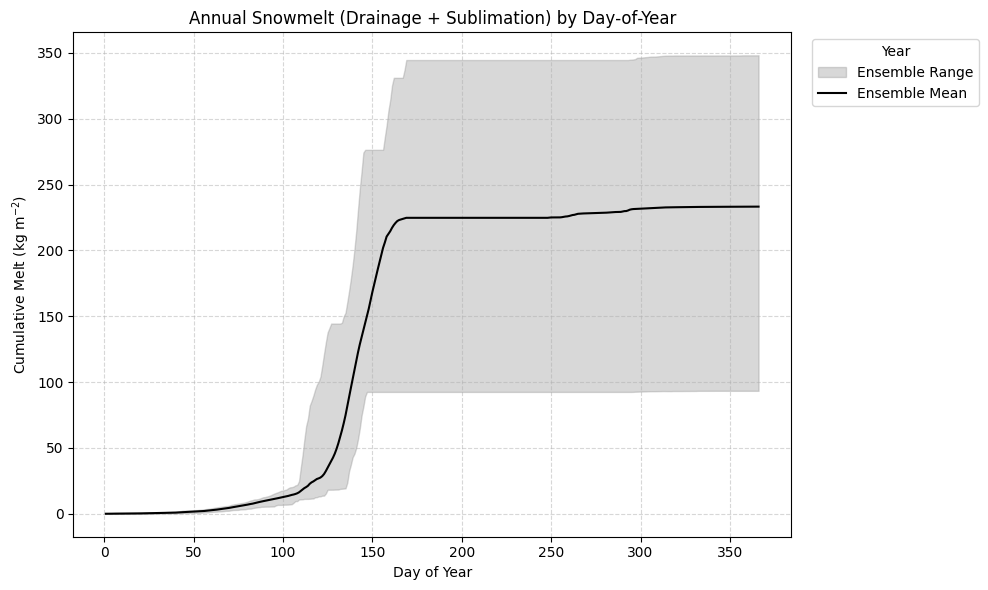

In [70]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from typing import Tuple, Optional

def plot_snowmelt_flux_by_doy(nc_path: str,
                              snow_density: float = 1000.0,
                              start_date: Optional[str] = None,
                              end_date: Optional[str] = None
                             ) -> Tuple[plt.Figure, plt.Axes]:
    """
    Plot annual cumulative snowmelt—defined as the sum of snow drainage and sublimation—
    as a function of day‐of‐year, with proper unit conversions.

    Parameters
    ----------
    nc_path : str
        Path to the NetCDF file containing:
          - `scalarSnowDrainage(time, hru)` in m s⁻¹,
          - `scalarSnowSublimation(time, hru)` in kg m⁻² s⁻¹,
          - and a CF‐compliant `time` coordinate.
    snow_density : float, default 1000.0
        Density of water in kg m⁻³ (to convert drainage to mass flux).
    start_date : str, optional
        Start date for the time constraint in 'YYYY-MM-DD' format.
    end_date : str, optional
        End date for the time constraint in 'YYYY-MM-DD' format.

    Returns
    -------
    fig : matplotlib.figure.Figure
        The figure object containing the plot.
    ax : matplotlib.axes.Axes
        The axes object of the plot.
    """
    # 1. Open dataset and extract first HRU's drainage (m/s) + sublimation (kg/m²/s)
    ds = xr.open_dataset(nc_path, decode_times=True)
    
    # Apply time constraints if provided
    if start_date or end_date:
        ds = ds.sel(time=slice(start_date, end_date))
    
    drain_mps = ds["scalarSnowDrainage_total"].isel(hru=0).to_series()
    subl_kg = ds["scalarSnowSublimation_total"].isel(hru=0).to_series()

    # 2. Convert drainage to mass flux (kg m⁻² s⁻¹) via ρ_w * (m/s)
    drain_kg = drain_mps * snow_density

    # 3. Instantaneous total melt flux (kg m⁻² s⁻¹)
    flux = drain_kg - subl_kg

    # 4. Ensure datetime index
    flux.index = pd.to_datetime(flux.index)

    # 5. Resample to daily total melt (sum of flux over each day)
    #    Summation yields kg m⁻² per second; multiply by 86400 s/day for kg m⁻²/day
    flux_daily = flux.resample("D").sum()

    # 6. Group by calendar year
    grouped = flux_daily.groupby(flux_daily.index.year)

    # Initialize DataFrames to store cumulative melts for each year
    yearly_data = {}
    
    for year, series in grouped:
        if series.empty or len(series) == 0:
            continue
            
        # Create daily cumulative sum series
        cum_melt = series.cumsum()
        
        # Create a full-year daily series including Feb 29 for all years
        year_dates = pd.date_range(start=f"{year}-01-01", end=f"{year}-12-31", freq='D')
        doys = year_dates.dayofyear
        
        # Initialize array for 366 days
        year_data = np.zeros(366)
        
        # Fill in the data we have
        year_data[doys - 1] = cum_melt.values
        
        # Forward fill any missing values
        for i in range(1, len(year_data)):
            if year_data[i] == 0:
                year_data[i] = year_data[i-1]
        
        yearly_data[year] = year_data

    # Create DataFrame with aligned data
    doy_index = np.arange(1, 367)  # 1-366 inclusive
    all_cum_melts = pd.DataFrame(yearly_data, index=doy_index)

    # Calculate statistics
    cum_melt_mean = all_cum_melts.mean(axis=1)
    cum_melt_min = all_cum_melts.min(axis=1)
    cum_melt_max = all_cum_melts.max(axis=1)

    # Plot ensemble ranges
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.fill_between(doy_index, cum_melt_min, cum_melt_max, color='gray', alpha=0.3, label='Ensemble Range')
    ax.plot(doy_index, cum_melt_mean, color='black', label='Ensemble Mean')

    # 8. Decorate
    ax.set_xlabel("Day of Year")
    ax.set_ylabel("Cumulative Melt (kg m$^{-2}$)")
    ax.set_title("Annual Snowmelt (Drainage + Sublimation) by Day‐of‐Year")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, prune="both"))
    ax.legend(title="Year", bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout()

    return fig, ax


# Example usage in a Jupyter notebook cell:
# %matplotlib inline

fig, ax = plot_snowmelt_flux_by_doy("/Users/dcasson/Data/bow_snow_experiments/lumped/output/run1_timestep.nc", start_date="2001-01-01", end_date="2018-12-31")
plt.show()